# Person A — Notebook 4 v2: Circuit Comparison (Expt 2, Polished)
**CS 590NN | Amogh | Apr 18 — polished version**

Tests whether the **localization signal** matters for circuit-targeted unlearning.
Hold everything else constant (same 50 CounterFact samples, same KL-stabilized
4-step protocol from Notebook 3 v2, same step count) and vary which MLP layers
(and attention heads) we unfreeze.

| Method | Localization signal |
|---|---|
| `OurMethod_ACDC` | ACDC v2.1 circuits from `week2_circuit_log_v2.1.json` |
| `OurMethod_ROMEtrace` | Top-K MLP layers from Meng et al. causal tracing (computed inline) |
| `OurMethod_Random` | Per-sample random K MLP layers, K matched to ACDC circuit size |

**Polish vs v1:**
1. KL measured AFTER optimizer step via fresh forward pass (Notebook 3 v2 fix).
2. Per-sample KL and p_new trajectories tracked.
3. Gradient clipping at max_norm=1.0.
4. Per-sample try/except — one failure won't kill 3×50 run.
5. **Pareto plot** (edit_success vs KL) and bar chart inline.
6. Output: `week6_comparison_output_v2.json` (doesn't clobber v1).

**Hypothesis:** ACDC's circuits localize the edit more tightly → lowest KL drift
at fixed edit_success. ROME-trace single-layer is most generalizing (high
edit_success, possibly higher drift). Random is a sanity floor.

**Runtime estimate:** ~30–40 min on H100 for 50 samples × 3 methods at n_steps=5.


### 4.0 Install

In [ ]:
import subprocess, sys, os

def pip(args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + args)

pip(["numpy==1.26.4"])
pip(["transformer-lens", "transformers", "datasets", "accelerate", "einops", "jaxtyping"])
pip(["matplotlib"])

print("Done. Restarting runtime...")
os.kill(os.getpid(), 9)


### 4.1 Imports

In [1]:
import torch, json, re, requests, random, traceback
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformer_lens import HookedTransformer
import matplotlib.pyplot as plt
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f"GPU    : {torch.cuda.get_device_name(0)} ({total/1e9:.0f} GB)")

assert tuple(int(x) for x in np.__version__.split(".")[:2]) < (2, 0)

torch.manual_seed(42)
random.seed(42)
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
FIGS_DIR = Path("figures")
FIGS_DIR.mkdir(exist_ok=True)
print("Imports OK")


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB (85 GB)
Imports OK


### 4.2 Load Model

In [2]:
MODEL_NAME_PRIMARY  = "Qwen/Qwen3-0.6B"
MODEL_NAME_FALLBACK = "Qwen/Qwen2.5-0.5B"

def load_model(name):
    return HookedTransformer.from_pretrained(
        name,
        center_unembed=True,
        center_writing_weights=False,
        fold_ln=True,
        refactor_factored_attn_matrices=False,
        device=DEVICE,
    )

try:
    model = load_model(MODEL_NAME_PRIMARY)
    MODEL_NAME = MODEL_NAME_PRIMARY
except Exception as e:
    print(f"Primary failed ({e}). Using fallback...")
    model = load_model(MODEL_NAME_FALLBACK)
    MODEL_NAME = MODEL_NAME_FALLBACK

model.set_use_attn_result(True)
model.eval()
model.tokenizer.pad_token = model.tokenizer.eos_token
print(f"Loaded : {MODEL_NAME} | {model.cfg.n_layers} layers | {model.cfg.n_heads} heads")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
Loaded : Qwen/Qwen3-0.6B | 28 layers | 16 heads


### 4.3 Upload ACDC Circuit Log
Upload `week2_circuit_log_v2.1.json` from Notebook 1 v2.1 (threshold-fixed).

In [4]:
from google.colab import files
print("Upload week2_circuit_log_v2.1.json from Notebook 1 v2.1...")
uploaded = files.upload()
log_path = next(iter(uploaded.keys()))
with open(log_path) as f:
    acdc_log = json.load(f)
print(f"Loaded {len(acdc_log)} ACDC circuits from {log_path}")
print(f"Avg n_mlp:  {sum(e['n_mlp']  for e in acdc_log)/len(acdc_log):.2f}")
print(f"Avg n_attn: {sum(e['n_attn'] for e in acdc_log)/len(acdc_log):.2f}")
n_clamped = sum(1 for e in acdc_log if e.get('effect_clamped', False))
print(f"Effect-clamped samples: {n_clamped}/{len(acdc_log)}")


Upload week2_circuit_log_v2.1.json from Notebook 1 v2.1...


Saving week2_circuit_log_v2.2.json to week2_circuit_log_v2.2.json
Loaded 50 ACDC circuits from week2_circuit_log_v2.2.json
Avg n_mlp:  6.52
Avg n_attn: 9.22
Effect-clamped samples: 5/50


### 4.4 Load CounterFact (50 samples)

In [5]:
@dataclass
class EditSample:
    prompt:          str
    target_new:      str
    target_true:     str
    subject:         str = ""
    related_prompts: List[str] = field(default_factory=list)

print("Downloading CounterFact...")
raw_data = requests.get("https://rome.baulab.info/data/dsets/counterfact.json", timeout=60).json()
print(f"Downloaded {len(raw_data)} records")

N_SAMPLES = 50

def parse_counterfact(raw):
    return EditSample(
        prompt=raw["requested_rewrite"]["prompt"].format(raw["requested_rewrite"]["subject"]),
        target_new=" "  + raw["requested_rewrite"]["target_new"]["str"],
        target_true=" " + raw["requested_rewrite"]["target_true"]["str"],
        subject=raw["requested_rewrite"]["subject"],
    )

cf_samples = [parse_counterfact(raw_data[i]) for i in range(N_SAMPLES)]
assert len(cf_samples) == len(acdc_log)
print(f"Loaded {N_SAMPLES} samples, aligned with ACDC log")


Downloaded 21919 records
Loaded 50 samples, aligned with ACDC log


### 4.5 ROME-Trace (Causal Tracing) Localization

Per Meng et al. 2022. For each sample:
1. Run clean: cache MLP outputs at every (layer, position).
2. Run corrupted: add Gaussian noise to subject token embeddings.
3. For each layer L, restore the **clean** MLP output at L at the last
   subject-token position; measure indirect effect = `p_restored − p_corrupt`.
4. Top-K layers by indirect effect become the ROME-trace circuit.

In [6]:
NOISE_SIGMA = 0.1
TOP_K_TRACE = 5

def find_subject_range(model, prompt, subject):
    full_tok = model.to_tokens(prompt)[0].tolist()
    pre_idx  = prompt.find(subject)
    if pre_idx < 0:
        return max(0, len(full_tok) - 3), len(full_tok)
    prefix   = prompt[:pre_idx]
    pre_tok  = model.to_tokens(prefix)[0].tolist()
    start    = len(pre_tok)
    sub_tok  = model.to_tokens(prompt[:pre_idx + len(subject)])[0].tolist()
    end      = len(sub_tok)
    return start, end


def causal_trace(model, sample, n_noise_samples=3):
    tokens   = model.to_tokens(sample.prompt)
    new_id   = model.to_tokens(sample.target_new,  prepend_bos=False)[0, 0].item()
    s_start, s_end = find_subject_range(model, sample.prompt, sample.subject)

    with torch.no_grad():
        clean_logits, clean_cache = model.run_with_cache(tokens)
    clean_p_new = torch.softmax(clean_logits[0, -1, :], dim=-1)[new_id].item()

    def noise_hook(name):
        def fn(emb, hook):
            noise = torch.randn_like(emb[:, s_start:s_end, :]) * NOISE_SIGMA
            emb[:, s_start:s_end, :] = emb[:, s_start:s_end, :] + noise
            return emb
        return fn

    corrupt_p_new_avg = 0.0
    for _ in range(n_noise_samples):
        with torch.no_grad():
            corrupt_logits = model.run_with_hooks(
                tokens,
                fwd_hooks=[("hook_embed", noise_hook("hook_embed"))],
            )
        corrupt_p_new_avg += torch.softmax(corrupt_logits[0, -1, :], dim=-1)[new_id].item()
    corrupt_p_new_avg /= n_noise_samples

    indirect_effects = {}
    restore_pos = s_end - 1
    for L in range(model.cfg.n_layers):
        hn = f"blocks.{L}.hook_mlp_out"
        clean_act = clean_cache[hn][:, restore_pos:restore_pos+1, :].clone()

        def restore_hook(act=clean_act, pos=restore_pos):
            def fn(v, hook):
                v[:, pos:pos+1, :] = act
                return v
            return fn

        torch.manual_seed(42)
        p_restored_avg = 0.0
        for _ in range(n_noise_samples):
            with torch.no_grad():
                restored_logits = model.run_with_hooks(
                    tokens,
                    fwd_hooks=[
                        ("hook_embed", noise_hook("hook_embed")),
                        (hn, restore_hook()),
                    ],
                )
            p_restored_avg += torch.softmax(restored_logits[0, -1, :], dim=-1)[new_id].item()
        p_restored_avg /= n_noise_samples
        indirect_effects[L] = p_restored_avg - corrupt_p_new_avg

    del clean_cache, clean_logits
    torch.cuda.empty_cache()
    return indirect_effects, clean_p_new, corrupt_p_new_avg


print(f"Running ROME-trace on {N_SAMPLES} samples (top-{TOP_K_TRACE} per sample)...")
trace_circuits = []
for i, s in enumerate(cf_samples):
    try:
        effects, clean_p, corrupt_p = causal_trace(model, s)
        top_layers = sorted(effects.items(), key=lambda x: -x[1])[:TOP_K_TRACE]
        trace_circuits.append({
            "idx": i,
            "mlp_layers": sorted([L for L, _ in top_layers]),
            "attn_heads": [],
            "n_mlp":  TOP_K_TRACE,
            "n_attn": 0,
            "top_effects": [(int(L), round(e, 4)) for L, e in top_layers],
            "clean_p_target_new":   round(clean_p, 4),
            "corrupt_p_target_new": round(corrupt_p, 4),
        })
        if i % 10 == 0:
            free = torch.cuda.mem_get_info()[0] / 1e9
            top_str = ",".join(str(L) for L, _ in top_layers)
            print(f"  [{i+1:>2}/{N_SAMPLES}]  top_layers=[{top_str}]  gpu_free={free:.1f}GB")
    except Exception as e:
        print(f"  [{i+1:>2}/{N_SAMPLES}]  TRACE FAILED: {type(e).__name__}: {str(e)[:80]}")
        # Fallback: use middle 5 layers
        mid = model.cfg.n_layers // 2
        trace_circuits.append({
            "idx": i, "mlp_layers": list(range(mid-2, mid+3)),
            "attn_heads": [], "n_mlp": 5, "n_attn": 0,
            "top_effects": [], "clean_p_target_new": 0.0, "corrupt_p_target_new": 0.0,
            "trace_failed": True,
        })

with open(RESULTS_DIR / "week6_rome_trace_circuits.json", "w") as f:
    json.dump(trace_circuits, f, indent=2)
print(f"Saved -> {RESULTS_DIR}/week6_rome_trace_circuits.json")


Running ROME-trace on 50 samples (top-5 per sample)...
  [ 1/50]  top_layers=[9,14,15,12,11]  gpu_free=81.3GB
  [11/50]  top_layers=[1,2,0,19,22]  gpu_free=81.3GB
  [21/50]  top_layers=[5,4,0,3,1]  gpu_free=81.3GB
  [31/50]  top_layers=[2,4,1,0,12]  gpu_free=81.3GB
  [41/50]  top_layers=[4,5,6,16,8]  gpu_free=81.3GB
Saved -> results/week6_rome_trace_circuits.json


### 4.6 Random Circuits (size-matched per sample to ACDC)

In [7]:
random.seed(42)
random_circuits = []
for i, e in enumerate(acdc_log):
    K = e["n_mlp"]
    layers = sorted(random.sample(range(model.cfg.n_layers), min(K, model.cfg.n_layers)))
    random_circuits.append({
        "idx": i,
        "mlp_layers": layers,
        "attn_heads": [],
        "n_mlp": len(layers),
        "n_attn": 0,
    })
print(f"Generated {len(random_circuits)} random circuits, avg n_mlp = "
      f"{sum(c['n_mlp'] for c in random_circuits)/len(random_circuits):.2f}")


Generated 50 random circuits, avg n_mlp = 6.52


### 4.7 Edit Functions (v2 Polish — Same as Notebook 3 v2)

In [8]:
NEUTRAL_PROMPTS = [
    "The sum of two and three is", "Twelve divided by four equals",
    "The square root of nine is", "Ten times ten equals",
    "The capital of Japan is", "The largest ocean on Earth is the",
    "Mount Everest is located in the", "The Amazon River flows through",
    "Water boils at one hundred degrees", "The chemical symbol for gold is",
    "Plants produce oxygen through a process called", "The Earth orbits the",
    "A week contains seven", "The primary colors are red, blue, and",
    "Humans have two lungs and one", "A triangle has three",
    "The opposite of hot is", "A baby cat is called a",
    "The past tense of run is", "A group of fish is called a",
    "The Industrial Revolution began in the eighteenth",
    "The Renaissance was a period of cultural",
    "World War Two ended in the year", "The Wright Brothers invented the",
    "A computer's main processor is the", "The world wide web was invented by",
    "An algorithm is a sequence of", "The unit of electrical resistance is the",
    "Roses are typically red while violets are",
    "The sky appears blue because of light",
    "A year contains twelve", "The freezing point of water is zero degrees",
]
assert len(NEUTRAL_PROMPTS) == 32

def restore_weights(model, state):
    with torch.no_grad():
        for name, param in model.named_parameters():
            param.copy_(state[name])
    torch.cuda.empty_cache()

def cache_reference_logits(model, prompts):
    cache = []
    model.eval()
    with torch.no_grad():
        for p in prompts:
            tokens = model.to_tokens(p)
            logits = model(tokens)
            ref_lp = torch.log_softmax(logits[0, -1, :], dim=-1).detach().clone()
            cache.append((tokens, ref_lp))
    return cache

def get_circuit_params(model, circuit_attn, circuit_mlp):
    params = []
    for (layer, head) in circuit_attn:
        try: params.append(model.blocks[layer].attn.W_O)
        except Exception: pass
    for layer in circuit_mlp:
        try:
            params.append(model.blocks[layer].mlp.W_in)
            params.append(model.blocks[layer].mlp.W_out)
        except Exception: pass
    return params

def contrastive_loss(model, sample):
    tokens  = model.to_tokens(sample.prompt)
    new_id  = model.to_tokens(sample.target_new,  prepend_bos=False)[0, 0]
    true_id = model.to_tokens(sample.target_true, prepend_bos=False)[0, 0]
    logits  = model(tokens)
    lp = torch.nn.functional.log_softmax(logits[0, -1, :], dim=-1)
    loss = -lp[new_id] + lp[true_id]
    return loss, lp[new_id].exp().item(), lp[true_id].exp().item()

def kl_loss_neutral(model, ref_cache):
    total = 0.0
    for tokens, ref_lp in ref_cache:
        logits = model(tokens)
        edit_lp = torch.log_softmax(logits[0, -1, :], dim=-1)
        kl = (ref_lp.exp() * (ref_lp - edit_lp)).sum()
        total = total + kl
    return total / len(ref_cache)

def kl_loss_neutral_eval(model, ref_cache):
    total = 0.0
    model.eval()
    with torch.no_grad():
        for tokens, ref_lp in ref_cache:
            logits = model(tokens)
            edit_lp = torch.log_softmax(logits[0, -1, :], dim=-1)
            kl = (ref_lp.exp() * (ref_lp - edit_lp)).sum().item()
            total += kl
    return total / len(ref_cache)


def run_edit_with_kl_polished(model, sample, circuit_attn, circuit_mlp,
                              n_steps, lr=5e-3, beta_kl=0.1, grad_clip=1.0,
                              ref_cache=None):
    """Same polished edit fn as Notebook 3 v2."""
    params = get_circuit_params(model, circuit_attn, circuit_mlp)
    if not params:
        params = [p for layer in model.blocks for p in [layer.mlp.W_in, layer.mlp.W_out]]

    for p in model.parameters(): p.requires_grad_(False)
    for p in params: p.requires_grad_(True)
    optimizer = torch.optim.Adam(params, lr=lr)

    model.eval()
    with torch.no_grad():
        _, baseline, _ = contrastive_loss(model, sample)
    kl_initial = kl_loss_neutral_eval(model, ref_cache) if ref_cache is not None else 0.0

    kl_history, p_new_history = [], []
    for step in range(n_steps):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        loss, _, _ = contrastive_loss(model, sample)
        if ref_cache is not None and beta_kl > 0:
            kl = kl_loss_neutral(model, ref_cache)
            loss = loss + beta_kl * kl
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=grad_clip)
        optimizer.step()
        del loss

        # Measure AFTER step
        step_kl = kl_loss_neutral_eval(model, ref_cache) if ref_cache is not None else 0.0
        _, step_p_new, _ = contrastive_loss(model, sample)
        kl_history.append(step_kl)
        p_new_history.append(step_p_new)

    torch.cuda.empty_cache()
    model.eval()
    with torch.no_grad():
        _, final_p_new, final_p_true = contrastive_loss(model, sample)
    kl_final = kl_history[-1] if kl_history else 0.0

    for p in model.parameters(): p.requires_grad_(True)
    return {
        "edit_success":  final_p_new,
        "baseline_prob": baseline,
        "final_p_true":  final_p_true,
        "kl_initial":    kl_initial,
        "kl_final":      kl_final,
        "delta_kl":      kl_final - kl_initial,
        "kl_history":    [round(k, 4) for k in kl_history],
        "p_new_history": [round(p, 4) for p in p_new_history],
        "status":        "ok",
    }


print("Snapshotting original weights to CPU...")
original_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
torch.cuda.empty_cache()
free, _ = torch.cuda.mem_get_info()
print(f"GPU free: {free/1e9:.1f} GB")


Snapshotting original weights to CPU...
GPU free: 81.3 GB


### 4.8 Comparison Loop (3 methods × 50 samples × n_steps=5)

In [9]:
N_STEPS  = 5
LR       = 5e-3
BETA_KL  = 0.1
GRAD_CLIP = 1.0

methods = {
    "OurMethod_ACDC":      acdc_log,
    "OurMethod_ROMEtrace": trace_circuits,
    "OurMethod_Random":    random_circuits,
}

comparison_results = {m: [] for m in methods}

for method_name, circuits in methods.items():
    print(f"\n=== {method_name} ===")
    n_failed = 0
    for i in range(N_SAMPLES):
        try:
            restore_weights(model, original_state)
            ref_cache = cache_reference_logits(model, NEUTRAL_PROMPTS)
            res = run_edit_with_kl_polished(
                model, cf_samples[i],
                circuits[i].get("attn_heads", []),
                circuits[i]["mlp_layers"],
                n_steps=N_STEPS, lr=LR,
                beta_kl=BETA_KL, grad_clip=GRAD_CLIP,
                ref_cache=ref_cache,
            )
            res["idx"]     = i
            res["n_mlp"]   = circuits[i]["n_mlp"]
            res["n_attn"]  = circuits[i].get("n_attn", 0)
            res["n_steps"] = N_STEPS
            comparison_results[method_name].append(res)
            del ref_cache
            torch.cuda.empty_cache()
            if i % 10 == 0:
                free = torch.cuda.mem_get_info()[0] / 1e9
                print(f"  [{i+1:>2}/{N_SAMPLES}]  edit={res['edit_success']:.4f}  "
                      f"kl={res['kl_final']:.3f}  n_mlp={res['n_mlp']}  "
                      f"gpu_free={free:.1f}GB")
        except Exception as e:
            n_failed += 1
            print(f"  [{i+1:>2}/{N_SAMPLES}]  FAILED: {type(e).__name__}: {str(e)[:80]}")
            comparison_results[method_name].append({
                "idx": i, "n_steps": N_STEPS, "status": "failed",
                "error": f"{type(e).__name__}: {str(e)[:200]}",
                "edit_success": 0.0, "baseline_prob": 0.0, "final_p_true": 0.0,
                "kl_initial": 0.0, "kl_final": 0.0, "delta_kl": 0.0,
                "kl_history": [], "p_new_history": [],
                "n_mlp": circuits[i]["n_mlp"], "n_attn": circuits[i].get("n_attn", 0),
            })
            torch.cuda.empty_cache()

    ok = [r for r in comparison_results[method_name] if r.get("status") == "ok"]
    if ok:
        avg_e = sum(r["edit_success"] for r in ok) / len(ok)
        avg_k = sum(r["kl_final"]     for r in ok) / len(ok)
        flipped = sum(1 for r in ok if r["edit_success"] > 0.5)
        print(f"  SUMMARY  edit={avg_e:.4f}  kl_final={avg_k:.3f}  "
              f"flip={flipped}/{len(ok)}  failed={n_failed}")

restore_weights(model, original_state)



=== OurMethod_ACDC ===
  [ 1/50]  edit=0.9998  kl=29.713  n_mlp=1  gpu_free=81.1GB


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


  [11/50]  edit=1.0000  kl=59.195  n_mlp=0  gpu_free=79.0GB
  [21/50]  edit=0.0647  kl=15.685  n_mlp=9  gpu_free=77.2GB
  [31/50]  edit=1.0000  kl=38.321  n_mlp=20  gpu_free=76.2GB
  [41/50]  edit=1.0000  kl=38.891  n_mlp=7  gpu_free=75.2GB
  SUMMARY  edit=0.7902  kl_final=25.107  flip=40/50  failed=0

=== OurMethod_ROMEtrace ===
  [ 1/50]  edit=0.9998  kl=11.545  n_mlp=5  gpu_free=75.9GB
  [11/50]  edit=1.0000  kl=14.586  n_mlp=5  gpu_free=75.7GB
  [21/50]  edit=0.9999  kl=8.544  n_mlp=5  gpu_free=75.7GB
  [31/50]  edit=0.9998  kl=19.567  n_mlp=5  gpu_free=75.9GB
  [41/50]  edit=1.0000  kl=30.524  n_mlp=5  gpu_free=75.9GB
  SUMMARY  edit=0.9531  kl_final=18.303  flip=48/50  failed=0

=== OurMethod_Random ===
  [ 1/50]  edit=0.9999  kl=5.036  n_mlp=1  gpu_free=75.8GB
  [11/50]  edit=1.0000  kl=59.195  n_mlp=0  gpu_free=76.0GB
  [21/50]  edit=1.0000  kl=39.513  n_mlp=9  gpu_free=74.0GB
  [31/50]  edit=1.0000  kl=44.052  n_mlp=20  gpu_free=74.7GB
  [41/50]  edit=1.0000  kl=40.155  n_mlp=

### 4.9 Figures

Three figures for the Expt 2 section:
- `fig_pareto.png`: per-sample edit_success vs KL_final, colored by method
- `fig_method_bars.png`: mean edit_success and KL_final per method (bar chart)
- `fig_kl_trajectory_methods.png`: KL trajectory across 5 steps, one curve per method


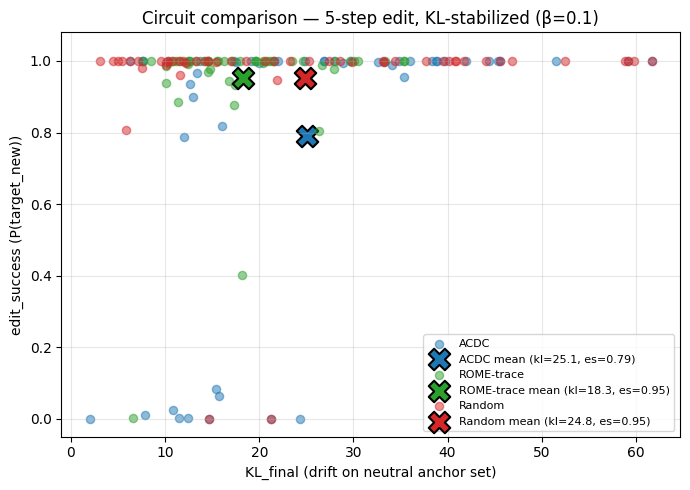

Saved -> figures/fig_pareto.png


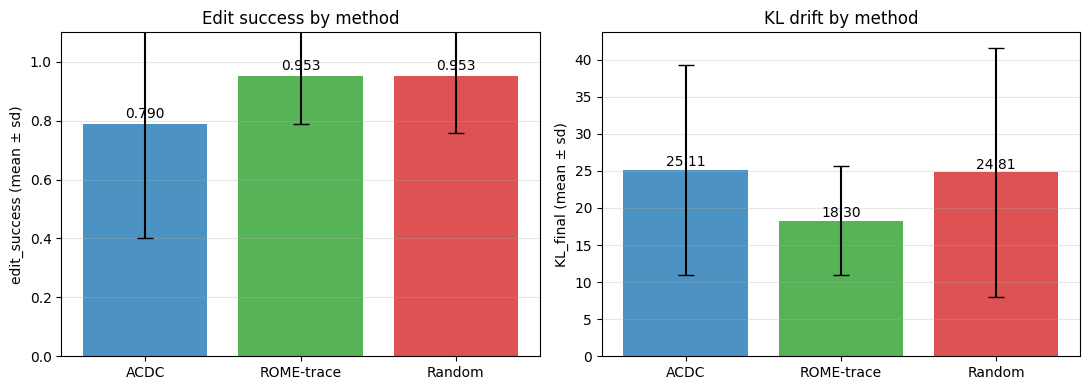

Saved -> figures/fig_method_bars.png


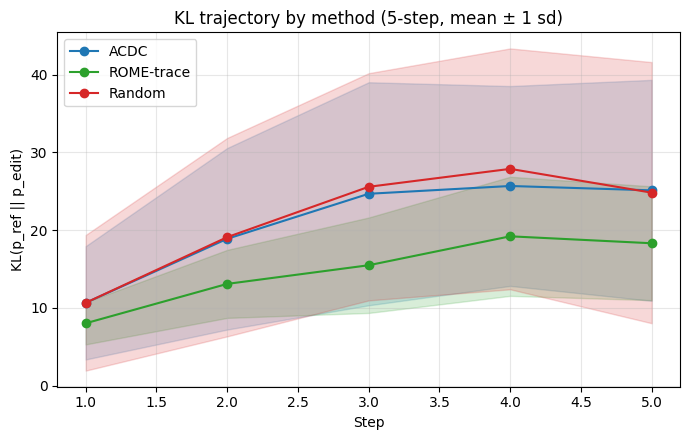

Saved -> figures/fig_kl_trajectory_methods.png


In [10]:
COLORS = {"OurMethod_ACDC": "C0", "OurMethod_ROMEtrace": "C2", "OurMethod_Random": "C3"}
LABELS = {"OurMethod_ACDC": "ACDC", "OurMethod_ROMEtrace": "ROME-trace", "OurMethod_Random": "Random"}

# ── Figure 1: Pareto plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for method, results in comparison_results.items():
    ok = [r for r in results if r.get("status") == "ok"]
    if not ok: continue
    es = [r["edit_success"] for r in ok]
    kl = [r["kl_final"]     for r in ok]
    ax.scatter(kl, es, c=COLORS[method], alpha=0.5, s=35, label=LABELS[method])
    # Method mean as a big marker
    mu_kl = sum(kl) / len(kl)
    mu_es = sum(es) / len(es)
    ax.scatter([mu_kl], [mu_es], c=COLORS[method], s=240, marker="X",
               edgecolors="black", linewidths=1.5,
               label=f"{LABELS[method]} mean (kl={mu_kl:.1f}, es={mu_es:.2f})")
ax.set_xlabel("KL_final (drift on neutral anchor set)")
ax.set_ylabel("edit_success (P(target_new))")
ax.set_title(f"Circuit comparison — {N_STEPS}-step edit, KL-stabilized (β={BETA_KL})")
ax.set_ylim(-0.05, 1.08)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_pareto.png", dpi=160)
plt.show()
print(f"Saved -> {FIGS_DIR}/fig_pareto.png")

# ── Figure 2: Method bar chart ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
mlist = list(methods.keys())
mu_es = []; sd_es = []; mu_kl = []; sd_kl = []
for m in mlist:
    ok = [r for r in comparison_results[m] if r.get("status") == "ok"]
    es = np.array([r["edit_success"] for r in ok])
    kl = np.array([r["kl_final"]     for r in ok])
    mu_es.append(es.mean()); sd_es.append(es.std())
    mu_kl.append(kl.mean()); sd_kl.append(kl.std())

x = np.arange(len(mlist))
ax1.bar(x, mu_es, yerr=sd_es, color=[COLORS[m] for m in mlist], capsize=6, alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels([LABELS[m] for m in mlist])
ax1.set_ylabel("edit_success (mean ± sd)")
ax1.set_ylim(0, 1.1)
ax1.set_title("Edit success by method")
ax1.grid(axis="y", alpha=0.3)
for xi, v in zip(x, mu_es):
    ax1.text(xi, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

ax2.bar(x, mu_kl, yerr=sd_kl, color=[COLORS[m] for m in mlist], capsize=6, alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels([LABELS[m] for m in mlist])
ax2.set_ylabel("KL_final (mean ± sd)")
ax2.set_title("KL drift by method")
ax2.grid(axis="y", alpha=0.3)
for xi, v in zip(x, mu_kl):
    ax2.text(xi, v + 0.5, f"{v:.2f}", ha="center", fontsize=10)
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_method_bars.png", dpi=160)
plt.show()
print(f"Saved -> {FIGS_DIR}/fig_method_bars.png")

# ── Figure 3: KL trajectory by method ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
for method, results in comparison_results.items():
    ok = [r for r in results if r.get("status") == "ok"]
    histories = [r["kl_history"] for r in ok if len(r["kl_history"]) == N_STEPS]
    if not histories: continue
    arr = np.array(histories)
    mu = arr.mean(axis=0); sd = arr.std(axis=0)
    xs = list(range(1, N_STEPS + 1))
    ax.plot(xs, mu, marker="o", color=COLORS[method], label=LABELS[method])
    ax.fill_between(xs, mu - sd, mu + sd, color=COLORS[method], alpha=0.18)
ax.set_xlabel("Step")
ax.set_ylabel("KL(p_ref || p_edit)")
ax.set_title(f"KL trajectory by method ({N_STEPS}-step, mean ± 1 sd)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_kl_trajectory_methods.png", dpi=160)
plt.show()
print(f"Saved -> {FIGS_DIR}/fig_kl_trajectory_methods.png")


### 4.10 Harness-Ready Output for Person B

In [11]:
rows, summary = [], {}
for method_name, results in comparison_results.items():
    for r in results:
        rows.append({
            "method":          method_name,
            "model":           MODEL_NAME,
            "idx":             r["idx"],
            "n_steps":         r["n_steps"],
            "edit_success":    round(r["edit_success"],  4),
            "baseline_prob":   round(r["baseline_prob"], 4),
            "over_extinction": None,
            "kl_initial":      round(r["kl_initial"],    4),
            "kl_final":        round(r["kl_final"],      4),
            "delta_kl":        round(r["delta_kl"],      4),
            "kl_history":      r["kl_history"],
            "p_new_history":   r["p_new_history"],
            "kl_active":       True,
            "beta_kl":         BETA_KL,
            "grad_clip":       GRAD_CLIP,
            "n_mlp":           r["n_mlp"],
            "n_attn":          r["n_attn"],
            "status":          r.get("status", "ok"),
            "error":           r.get("error", None),
        })
    ok = [r for r in results if r.get("status") == "ok"]
    if ok:
        summary[method_name] = {
            "avg_edit_success": round(sum(r["edit_success"] for r in ok) / len(ok), 4),
            "avg_kl_final":     round(sum(r["kl_final"]     for r in ok) / len(ok), 4),
            "avg_delta_kl":     round(sum(r["delta_kl"]     for r in ok) / len(ok), 4),
            "avg_n_mlp":        round(sum(r["n_mlp"]        for r in ok) / len(ok), 2),
            "pct_flipped":      round(sum(1 for r in ok if r["edit_success"] > 0.5) / len(ok), 4),
            "n_ok":             len(ok),
            "n_failed":         len(results) - len(ok),
        }

harness_output = {
    "experiment":       "circuit_comparison_expt2",
    "model":            MODEL_NAME,
    "n_steps":          N_STEPS,
    "beta_kl":          BETA_KL,
    "grad_clip":        GRAD_CLIP,
    "neutral_set_size": len(NEUTRAL_PROMPTS),
    "notebook_version": "v2_polished",
    "rows":             rows,
    "summary":          summary,
}
with open(RESULTS_DIR / "week6_comparison_output_v2.json", "w") as f:
    json.dump(harness_output, f, indent=2)

print(f"{'Method':<22}  {'edit':>6}  {'flip%':>6}  {'kl':>7}  {'n_mlp':>6}  {'ok/fail':>8}")
print("-" * 70)
for m, s in summary.items():
    print(f"{m:<22}  {s['avg_edit_success']:>6.4f}  "
          f"{100*s['pct_flipped']:>5.1f}%  {s['avg_kl_final']:>7.3f}  "
          f"{s['avg_n_mlp']:>6.2f}  {s['n_ok']}/{s['n_failed']}")


Method                    edit   flip%       kl   n_mlp   ok/fail
----------------------------------------------------------------------
OurMethod_ACDC          0.7902   80.0%   25.107    6.52  50/0
OurMethod_ROMEtrace     0.9531   96.0%   18.303    5.00  50/0
OurMethod_Random        0.9532   96.0%   24.809    6.52  50/0


### 4.11 Save and Download

In [12]:
import shutil
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_meta = {
    "author":           "Amogh",
    "notebook":         "Notebook 4 v2 — Circuit Comparison (Expt 2, Polished)",
    "model":            MODEL_NAME,
    "timestamp":        timestamp,
    "n_samples":        N_SAMPLES,
    "n_steps":          N_STEPS,
    "beta_kl":          BETA_KL,
    "grad_clip":        GRAD_CLIP,
    "methods":          list(methods.keys()),
    "notebook_version": "v2_polished",
    "fixes_applied":    [
        "KL measured after each step (Notebook 3 v2 fix)",
        "Per-step KL and p_new trajectories",
        "Gradient clipping at max_norm=1.0",
        "Per-sample try/except",
        "Three figures saved inline (Pareto, bars, trajectory)",
    ],
    "summary":          summary,
}
with open(RESULTS_DIR / f"summary_nb4v2_{timestamp}.json", "w") as f:
    json.dump(summary_meta, f, indent=2)

all_dir = Path("zip_contents")
all_dir.mkdir(exist_ok=True)
for p in RESULTS_DIR.glob("*"): shutil.copy2(p, all_dir / p.name)
for p in FIGS_DIR.glob("*"):    shutil.copy2(p, all_dir / p.name)

zip_path = f"/content/PersonA_Notebook4v2_results_{timestamp}"
shutil.make_archive(zip_path, "zip", all_dir)

print("=" * 70)
print(f"  NOTEBOOK 4 v2 RESULTS — Amogh  ({timestamp})")
print("=" * 70)
for m, s in summary.items():
    print(f"  {m:<22}  edit={s['avg_edit_success']:.4f}  "
          f"kl={s['avg_kl_final']:.3f}  flip%={100*s['pct_flipped']:>5.1f}  "
          f"n_mlp={s['avg_n_mlp']:.1f}")
print()
print("  Files in zip:")
for f in sorted(all_dir.glob("*")):
    print(f"    {f.name:<44}  {f.stat().st_size//1024:>4} KB")
print(f"\n  Download: {zip_path}.zip")

from google.colab import files
files.download(f"{zip_path}.zip")
print("\nDONE. Send week6_comparison_output_v2.json to Aneesh for live OE pass.")


  NOTEBOOK 4 v2 RESULTS — Amogh  (20260419_042815)
  OurMethod_ACDC          edit=0.7902  kl=25.107  flip%= 80.0  n_mlp=6.5
  OurMethod_ROMEtrace     edit=0.9531  kl=18.303  flip%= 96.0  n_mlp=5.0
  OurMethod_Random        edit=0.9532  kl=24.809  flip%= 96.0  n_mlp=6.5

  Files in zip:
    fig_kl_trajectory_methods.png                   92 KB
    fig_method_bars.png                             53 KB
    fig_pareto.png                                 105 KB
    summary_nb4v2_20260419_042815.json               1 KB
    week6_comparison_output_v2.json                 97 KB
    week6_rome_trace_circuits.json                  22 KB

  Download: /content/PersonA_Notebook4v2_results_20260419_042815.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE. Send week6_comparison_output_v2.json to Aneesh for live OE pass.
